<a href="https://colab.research.google.com/github/AliAI11/VitaCheck/blob/main/src/notebooks/HCICapstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# install dependencies
!pip install -q lightgbm xgboost scikit-learn pandas numpy shap \
    imbalanced-learn optuna joblib matplotlib seaborn

import torch

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    props = torch.cuda.get_device_properties(0)
    print(f'Memory: {props.total_memory / 1e9:.1f} GB')
else:
    print('No GPU detected, training will still work')

GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import os
import joblib

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb
import xgboost as xgb
import optuna
from imblearn.over_sampling import SMOTENC
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

np.random.seed(42)
print('all imports loaded')

all imports loaded


In [ ]:
# downloading the latest version of dataset
import kagglehub

path = kagglehub.dataset_download("nudratabbas/vitamin-deficiency-disease-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'vitamin-deficiency-disease-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/vitamin-deficiency-disease-prediction-dataset


In [ ]:
# load dataset
import pandas as pd

DATA_PATH = f"{path}/vitamin_deficiency_disease_dataset_20260123.csv"
df = pd.read_csv(DATA_PATH)

print(f'loaded {len(df)} records')
print(f'columns: {df.columns.tolist()}')
print(f'\nshape: {df.shape}')
print(f'\nmissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()

loaded 4000 records
columns: ['age', 'gender', 'bmi', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region', 'vitamin_a_percent_rda', 'vitamin_c_percent_rda', 'vitamin_d_percent_rda', 'vitamin_e_percent_rda', 'vitamin_b12_percent_rda', 'folate_percent_rda', 'calcium_percent_rda', 'iron_percent_rda', 'hemoglobin_g_dl', 'serum_vitamin_d_ng_ml', 'serum_vitamin_b12_pg_ml', 'serum_folate_ng_ml', 'symptoms_count', 'symptoms_list', 'has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin', 'disease_diagnosis', 'has_multiple_deficiencies']

shape: (4000, 34)

missing values:
alcohol_consumption    1278
symptoms_list          1328
dtype: int64


,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_multiple_deficiencies
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,1,0,0,0,0,0,0,0,Healthy,0
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,0,0,0,0,0,1,1,0,Anemia,0
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,0,0,0,0,0,0,0,0,Healthy,0


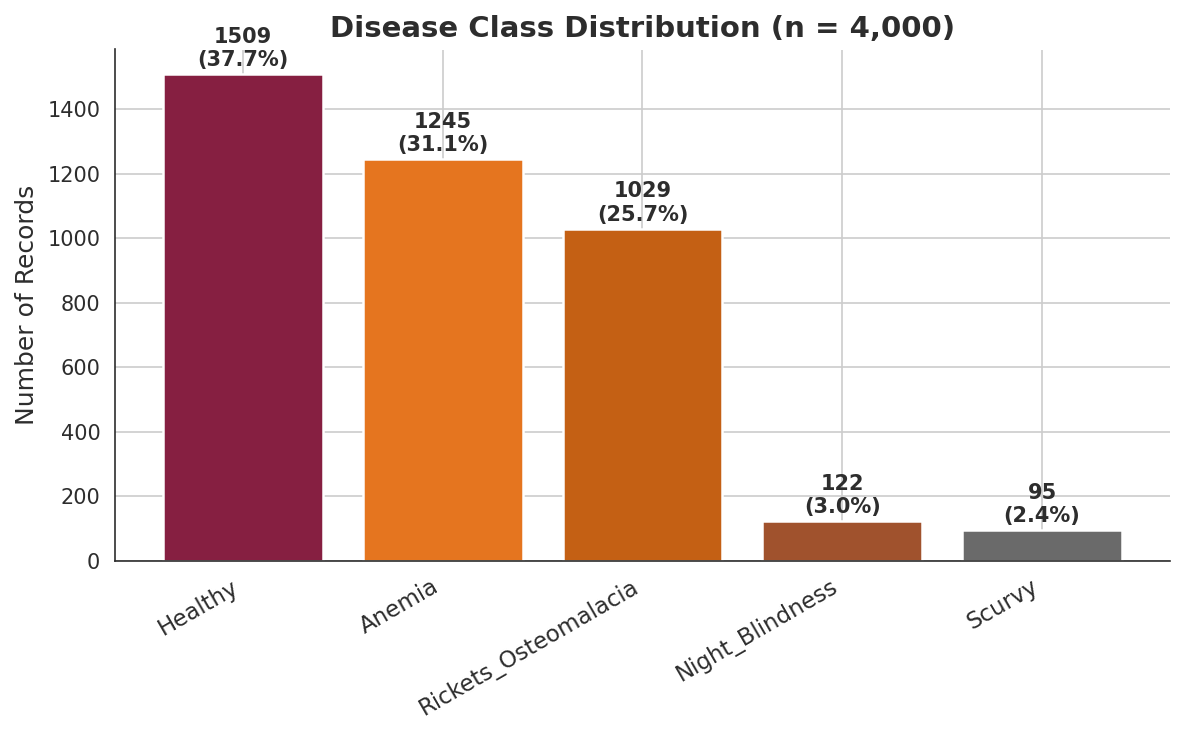


imbalance ratio: 1509:95 (15.9x)


In [ ]:
# vt color palette
VT_MAROON = '#861F41'
VT_ORANGE = '#E5751F'
VT_CREAM  = '#F0E8D8'
VT_GRAY   = '#6A6A6A'
VT_DARK   = '#2D2D2D'

CLASS_COLORS = ['#861F41', '#E5751F', '#C46014', '#A0522D', '#6A6A6A']

# global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': VT_DARK,
    'axes.labelcolor': VT_DARK,
    'text.color': VT_DARK,
    'xtick.color': VT_DARK,
    'ytick.color': VT_DARK,
    'font.family': 'sans-serif',
    'figure.dpi': 150,
})

# --- figure 1: class distribution ---
fig, ax = plt.subplots(figsize=(8, 5))

class_counts = df['disease_diagnosis'].value_counts()
bars = ax.bar(range(len(class_counts)), class_counts.values,
              color=CLASS_COLORS, edgecolor='white', linewidth=1.2)

for i, (idx, val) in enumerate(class_counts.items()):
    ax.text(i, val + 25, f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', fontsize=10, fontweight='bold', color=VT_DARK)

ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, rotation=30, ha='right', fontsize=11)
ax.set_ylabel('Number of Records', fontsize=12)
ax.set_title('Disease Class Distribution (n = 4,000)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/content/fig1_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nimbalance ratio: {class_counts.iloc[0]}:{class_counts.iloc[-1]} '
      f'({class_counts.iloc[0] / class_counts.iloc[-1]:.1f}x)')

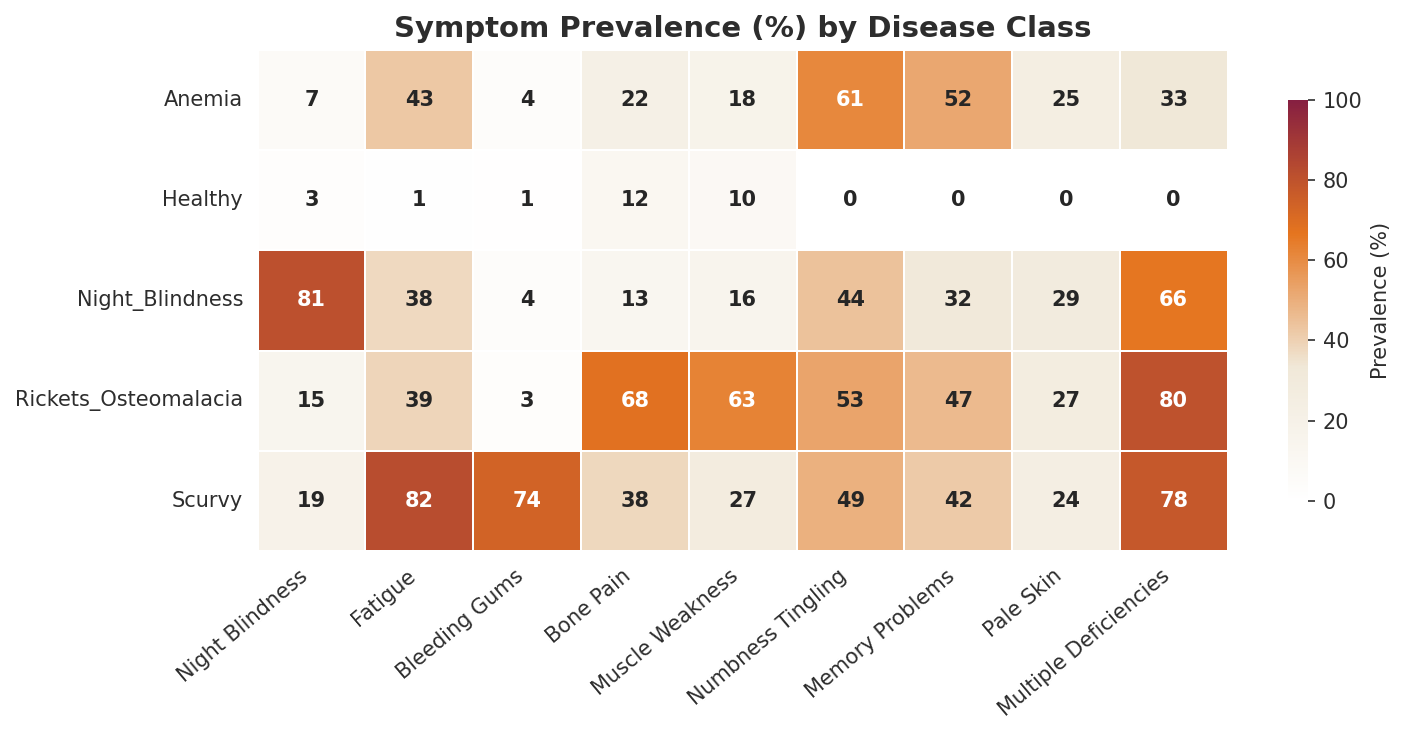

In [ ]:
# --- figure 2: symptom prevalence heatmap ---
symptom_cols = [c for c in df.columns if c.startswith('has_')]
symptom_prev = df.groupby('disease_diagnosis')[symptom_cols].mean() * 100

# custom maroon-orange colormap
from matplotlib.colors import LinearSegmentedColormap
vt_cmap = LinearSegmentedColormap.from_list('vt', ['#FFFFFF', VT_CREAM, VT_ORANGE, VT_MAROON])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(symptom_prev, annot=True, fmt='.0f', cmap=vt_cmap,
            linewidths=0.8, linecolor='white', ax=ax, vmin=0, vmax=100,
            cbar_kws={'label': 'Prevalence (%)', 'shrink': 0.8},
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})

ax.set_title('Symptom Prevalence (%) by Disease Class', fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('')
clean_labels = [c.replace('has_', '').replace('_', ' ').title() for c in symptom_cols]
ax.set_xticklabels(clean_labels, rotation=40, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)

plt.tight_layout()
plt.savefig('/content/fig2_symptom_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# preprocessing - remove leaky features
leaky_cols = [
    'symptoms_list',
    'hemoglobin_g_dl',
    'serum_vitamin_d_ng_ml',
    'serum_vitamin_b12_pg_ml',
    'serum_folate_ng_ml',
    'vitamin_a_percent_rda',
    'vitamin_c_percent_rda',
    'vitamin_d_percent_rda',
    'vitamin_e_percent_rda',
    'vitamin_b12_percent_rda',
    'folate_percent_rda',
    'calcium_percent_rda',
    'iron_percent_rda',
]

cols_to_drop = [c for c in leaky_cols if c in df.columns]
X = df.drop(columns=['disease_diagnosis'] + cols_to_drop)
y = df['disease_diagnosis']

# fill missing values
if 'alcohol_consumption' in X.columns:
    X['alcohol_consumption'] = X['alcohol_consumption'].fillna('Unknown')

# identify feature types
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=['number']).columns.tolist()

print(f'features after removing leaky columns: {X.shape[1]}')
print(f'  categorical ({len(categorical_features)}): {categorical_features}')
print(f'  numerical ({len(numerical_features)}): {numerical_features}')

features after removing leaky columns: 20
  categorical (8): ['gender', 'smoking_status', 'alcohol_consumption', 'exercise_level', 'diet_type', 'sun_exposure', 'income_level', 'latitude_region']
  numerical (12): ['age', 'bmi', 'symptoms_count', 'has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'has_numbness_tingling', 'has_memory_problems', 'has_pale_skin', 'has_multiple_deficiencies']


In [ ]:
# one-hot encode categoricals
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=False)

# track which columns are categorical for smote-nc
cat_feature_indices = []
for i, col in enumerate(X_encoded.columns):
    if col.startswith('has_') or any(col.startswith(f'{cf}_') for cf in categorical_features):
        cat_feature_indices.append(i)

# encode target
target_le = LabelEncoder()
y_encoded = target_le.fit_transform(y)
class_names = target_le.classes_

print(f'encoded feature matrix: {X_encoded.shape}')
print(f'categorical indices for smote-nc: {len(cat_feature_indices)} features')
print(f'classes: {list(class_names)}')
print(f'encoding: {dict(zip(class_names, range(len(class_names))))}')

encoded feature matrix: (4000, 37)
categorical indices for smote-nc: 34 features
classes: ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']
encoding: {'Anemia': 0, 'Healthy': 1, 'Night_Blindness': 2, 'Rickets_Osteomalacia': 3, 'Scurvy': 4}


In [ ]:
# stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# scale only continuous numerical features (not binary one-hot columns)
scaler = StandardScaler()
continuous_cols = ['age', 'bmi', 'symptoms_count']
continuous_cols = [c for c in continuous_cols if c in X_train.columns]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print(f'train: {X_train_scaled.shape}')
print(f'test: {X_test_scaled.shape}')
print(f'\ntrain class distribution:')
for cls_idx, cls_name in enumerate(class_names):
    count = (y_train == cls_idx).sum()
    print(f'  {cls_name}: {count} ({count/len(y_train)*100:.1f}%)')

train: (3200, 37)
test: (800, 37)

train class distribution:
  Anemia: 996 (31.1%)
  Healthy: 1207 (37.7%)
  Night_Blindness: 98 (3.1%)
  Rickets_Osteomalacia: 823 (25.7%)
  Scurvy: 76 (2.4%)


In [ ]:
# apply smote-nc to handle class imbalance (train set only)
print('applying smote-nc to balance training data')
print(f'\nbefore smote-nc:')
for cls_idx, cls_name in enumerate(class_names):
    print(f'  {cls_name}: {(y_train == cls_idx).sum()}')

smote_nc = SMOTENC(
    categorical_features=cat_feature_indices,
    random_state=42,
    k_neighbors=3  # lower k because minority classes are small
)

X_train_resampled, y_train_resampled = smote_nc.fit_resample(
    X_train_scaled, y_train
)

print(f'\nafter smote-nc:')
for cls_idx, cls_name in enumerate(class_names):
    print(f'  {cls_name}: {(y_train_resampled == cls_idx).sum()}')

print(f'\ntrain set grew from {len(y_train)} to {len(y_train_resampled)} samples')

applying smote-nc to balance training data

before smote-nc:
  Anemia: 996
  Healthy: 1207
  Night_Blindness: 98
  Rickets_Osteomalacia: 823
  Scurvy: 76

after smote-nc:
  Anemia: 1207
  Healthy: 1207
  Night_Blindness: 1207
  Rickets_Osteomalacia: 1207
  Scurvy: 1207

train set grew from 3200 to 6035 samples


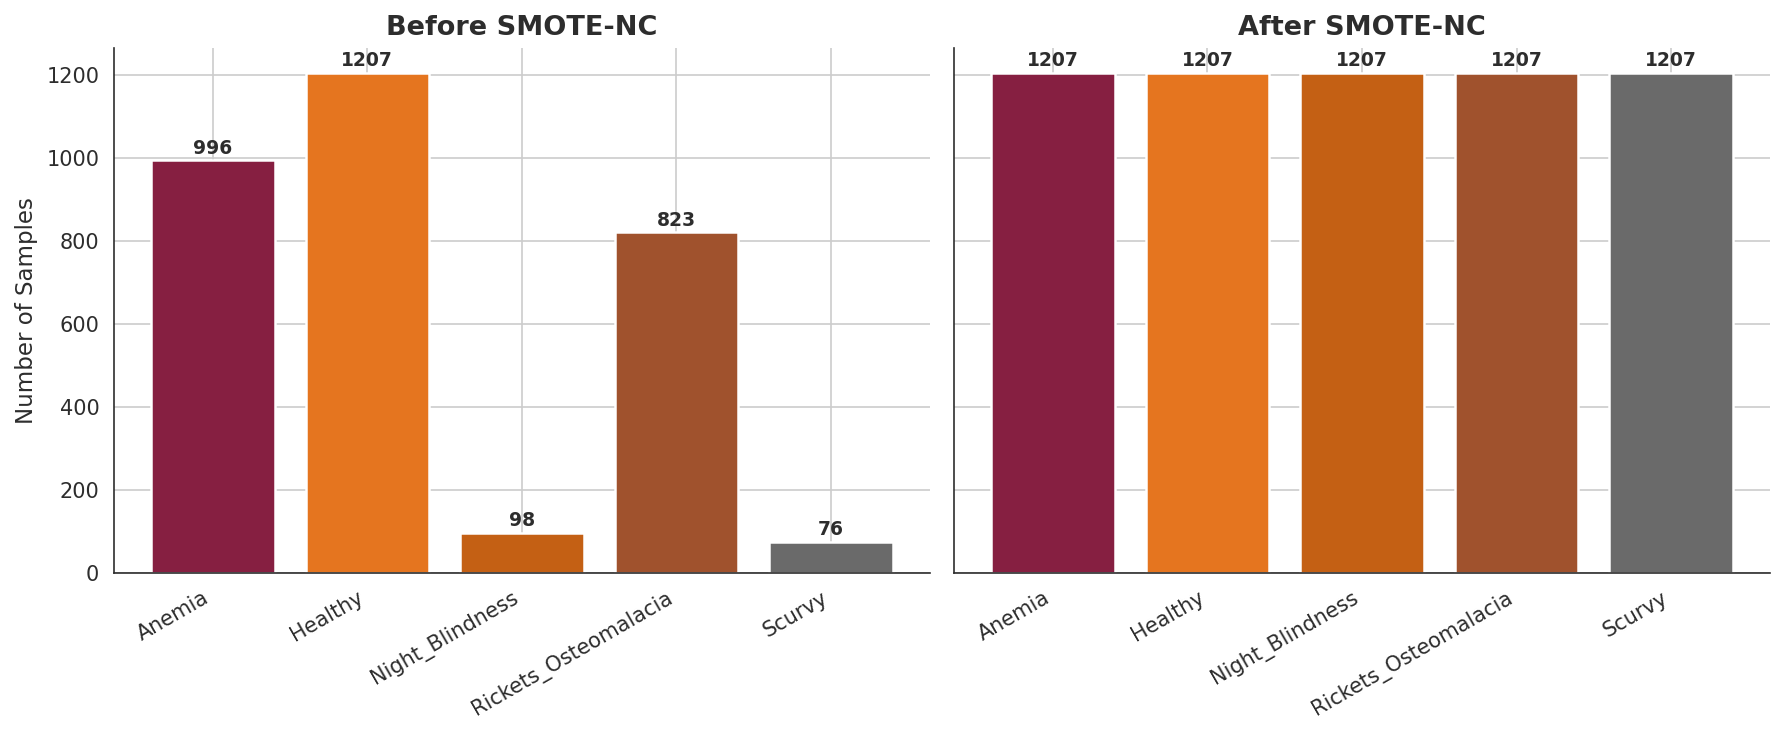

In [ ]:
# --- figure 3: smote-nc before vs after ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# before
before_counts = pd.Series(y_train).map(dict(enumerate(class_names))).value_counts().reindex(class_names)
axes[0].bar(range(len(before_counts)), before_counts.values,
            color=CLASS_COLORS, edgecolor='white', linewidth=1.2)
axes[0].set_title('Before SMOTE-NC', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].set_xticks(range(len(class_names)))
axes[0].set_xticklabels(class_names, rotation=30, ha='right', fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, val in enumerate(before_counts.values):
    axes[0].text(i, val + 15, str(val), ha='center', fontsize=9, fontweight='bold', color=VT_DARK)

# after
after_counts = pd.Series(y_train_resampled).map(dict(enumerate(class_names))).value_counts().reindex(class_names)
axes[1].bar(range(len(after_counts)), after_counts.values,
            color=CLASS_COLORS, edgecolor='white', linewidth=1.2)
axes[1].set_title('After SMOTE-NC', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(class_names)))
axes[1].set_xticklabels(class_names, rotation=30, ha='right', fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, val in enumerate(after_counts.values):
    axes[1].text(i, val + 15, str(val), ha='center', fontsize=9, fontweight='bold', color=VT_DARK)

plt.tight_layout()
plt.savefig('/content/fig3_smote_effect.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# train baseline models WITHOUT smote (for comparison)
print('training baselines without smote-nc...\n')

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'LightGBM': lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                                     num_leaves=31, random_state=42, verbose=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=500, learning_rate=0.05,
                                  max_depth=6, eval_metric='mlogloss',
                                  random_state=42, device='cuda')
}

baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    baseline_results[name] = {'accuracy': acc, 'macro_f1': f1}
    print(f'{name}: accuracy={acc:.4f}, macro_f1={f1:.4f}')

print('\nbaselines trained (no smote)')

training baselines without smote-nc...

Logistic Regression: accuracy=0.8313, macro_f1=0.6618
Random Forest: accuracy=0.8475, macro_f1=0.6523
LightGBM: accuracy=0.8313, macro_f1=0.6487
XGBoost: accuracy=0.8287, macro_f1=0.6791

baselines trained (no smote)


In [ ]:
# train models WITH smote-nc balanced data
print('training models with smote-nc balanced data...\n')

smote_models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42),
    'LightGBM': lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
                                     num_leaves=31, random_state=42, verbose=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=500, learning_rate=0.05,
                                  max_depth=6, eval_metric='mlogloss',
                                  random_state=42, device='cuda')
}

smote_results = {}
for name, model in smote_models.items():
    model.fit(X_train_resampled, y_train_resampled)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')
    smote_results[name] = {'accuracy': acc, 'macro_f1': f1}
    print(f'{name}: accuracy={acc:.4f}, macro_f1={f1:.4f}')

print('\nsmote models trained')

training models with smote-nc balanced data...

Logistic Regression: accuracy=0.8137, macro_f1=0.6852
Random Forest: accuracy=0.8337, macro_f1=0.6923
LightGBM: accuracy=0.8337, macro_f1=0.6828
XGBoost: accuracy=0.8337, macro_f1=0.6888

smote models trained


In [ ]:
# hyperparameter tuning with optuna - xgboost
print('tuning xgboost with optuna... ')

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'device': 'cuda'
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train_resampled, y_train_resampled):
        X_cv_train = X_train_resampled.iloc[train_idx] if hasattr(X_train_resampled, 'iloc') else X_train_resampled[train_idx]
        X_cv_val = X_train_resampled.iloc[val_idx] if hasattr(X_train_resampled, 'iloc') else X_train_resampled[val_idx]
        y_cv_train = y_train_resampled[train_idx]
        y_cv_val = y_train_resampled[val_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(X_cv_train, y_cv_train, verbose=False)
        preds = model.predict(X_cv_val)
        scores.append(f1_score(y_cv_val, preds, average='macro'))

    return np.mean(scores)

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=100, show_progress_bar=True)

print(f'\nbest xgboost macro f1 (cv): {xgb_study.best_value:.4f}')
print(f'best params: {json.dumps(xgb_study.best_params, indent=2)}')

tuning xgboost with optuna... 


  0%|          | 0/100 [00:00<?, ?it/s]


best xgboost macro f1 (cv): 0.9184
best params: {
  "n_estimators": 244,
  "max_depth": 7,
  "learning_rate": 0.08861653727486049,
  "subsample": 0.9268647370728459,
  "colsample_bytree": 0.6010957133818308,
  "min_child_weight": 1,
  "gamma": 0.09419131557154324,
  "reg_alpha": 5.414679160157618e-08,
  "reg_lambda": 1.3807596868037433e-07
}


In [ ]:
# hyperparameter tuning with optuna - lightgbm
print('tuning lightgbm with optuna...\n')

def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'verbose': -1
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train_resampled, y_train_resampled):
        X_cv_train = X_train_resampled.iloc[train_idx] if hasattr(X_train_resampled, 'iloc') else X_train_resampled[train_idx]
        X_cv_val = X_train_resampled.iloc[val_idx] if hasattr(X_train_resampled, 'iloc') else X_train_resampled[val_idx]
        y_cv_train = y_train_resampled[train_idx]
        y_cv_val = y_train_resampled[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_cv_train, y_cv_train)
        preds = model.predict(X_cv_val)
        scores.append(f1_score(y_cv_val, preds, average='macro'))

    return np.mean(scores)

lgb_study = optuna.create_study(direction='maximize')
lgb_study.optimize(lgb_objective, n_trials=100, show_progress_bar=True)

print(f'\nbest lightgbm macro f1 (cv): {lgb_study.best_value:.4f}')
print(f'best params: {json.dumps(lgb_study.best_params, indent=2)}')

tuning lightgbm with optuna...



  0%|          | 0/100 [00:00<?, ?it/s]


best lightgbm macro f1 (cv): 0.9198
best params: {
  "n_estimators": 1154,
  "num_leaves": 83,
  "learning_rate": 0.010044770025919976,
  "subsample": 0.5976138401961941,
  "colsample_bytree": 0.5720315317424631,
  "min_child_samples": 14,
  "reg_alpha": 1.8625729784408145e-05,
  "reg_lambda": 0.000171622145463929
}


In [ ]:
# train final tuned models with best params
print('training final tuned models...\n')

# xgboost tuned
best_xgb_params = xgb_study.best_params
best_xgb_params['eval_metric'] = 'mlogloss'
best_xgb_params['random_state'] = 42
best_xgb_params['device'] = 'cuda'

xgb_tuned = xgb.XGBClassifier(**best_xgb_params)
xgb_tuned.fit(X_train_resampled, y_train_resampled)

xgb_preds = xgb_tuned.predict(X_test_scaled)
print(f'xgboost tuned: accuracy={accuracy_score(y_test, xgb_preds):.4f}, '
      f'macro_f1={f1_score(y_test, xgb_preds, average="macro"):.4f}')

# lightgbm tuned
best_lgb_params = lgb_study.best_params
best_lgb_params['random_state'] = 42
best_lgb_params['verbose'] = -1

lgb_tuned = lgb.LGBMClassifier(**best_lgb_params)
lgb_tuned.fit(X_train_resampled, y_train_resampled)

lgb_preds = lgb_tuned.predict(X_test_scaled)
print(f'lightgbm tuned: accuracy={accuracy_score(y_test, lgb_preds):.4f}, '
      f'macro_f1={f1_score(y_test, lgb_preds, average="macro"):.4f}')

# pick the best overall model
xgb_f1 = f1_score(y_test, xgb_preds, average='macro')
lgb_f1 = f1_score(y_test, lgb_preds, average='macro')

if xgb_f1 >= lgb_f1:
    best_model = xgb_tuned
    best_model_name = 'XGBoost (Tuned)'
    best_preds = xgb_preds
    best_f1 = xgb_f1
else:
    best_model = lgb_tuned
    best_model_name = 'LightGBM (Tuned)'
    best_preds = lgb_preds
    best_f1 = lgb_f1

print(f'\nbest model: {best_model_name} (macro_f1={best_f1:.4f})')

training final tuned models...

xgboost tuned: accuracy=0.8413, macro_f1=0.7027
lightgbm tuned: accuracy=0.8375, macro_f1=0.6828

best model: XGBoost (Tuned) (macro_f1=0.7027)


In [ ]:
# full model comparison summary
print('final model comparison\n')

all_results = {}

# baselines without smote
for name in baseline_results:
    all_results[f'{name} (no smote)'] = baseline_results[name]

# smote models with default params
for name in smote_results:
    all_results[f'{name} (smote)'] = smote_results[name]

# tuned models
all_results['XGBoost (tuned+smote)'] = {
    'accuracy': accuracy_score(y_test, xgb_preds),
    'macro_f1': f1_score(y_test, xgb_preds, average='macro')
}
all_results['LightGBM (tuned+smote)'] = {
    'accuracy': accuracy_score(y_test, lgb_preds),
    'macro_f1': f1_score(y_test, lgb_preds, average='macro')
}

print(f'{"Model":<35} {"Accuracy":>10} {"Macro F1":>10}')
print('=' * 57)
for name, res in sorted(all_results.items(), key=lambda x: x[1]['macro_f1'], reverse=True):
    print(f'{name:<35} {res["accuracy"]:>10.4f} {res["macro_f1"]:>10.4f}')

final model comparison

Model                                 Accuracy   Macro F1
XGBoost (tuned+smote)                   0.8413     0.7027
Random Forest (smote)                   0.8337     0.6923
XGBoost (smote)                         0.8337     0.6888
Logistic Regression (smote)             0.8137     0.6852
LightGBM (tuned+smote)                  0.8375     0.6828
LightGBM (smote)                        0.8337     0.6828
XGBoost (no smote)                      0.8287     0.6791
Logistic Regression (no smote)          0.8313     0.6618
Random Forest (no smote)                0.8475     0.6523
LightGBM (no smote)                     0.8313     0.6487


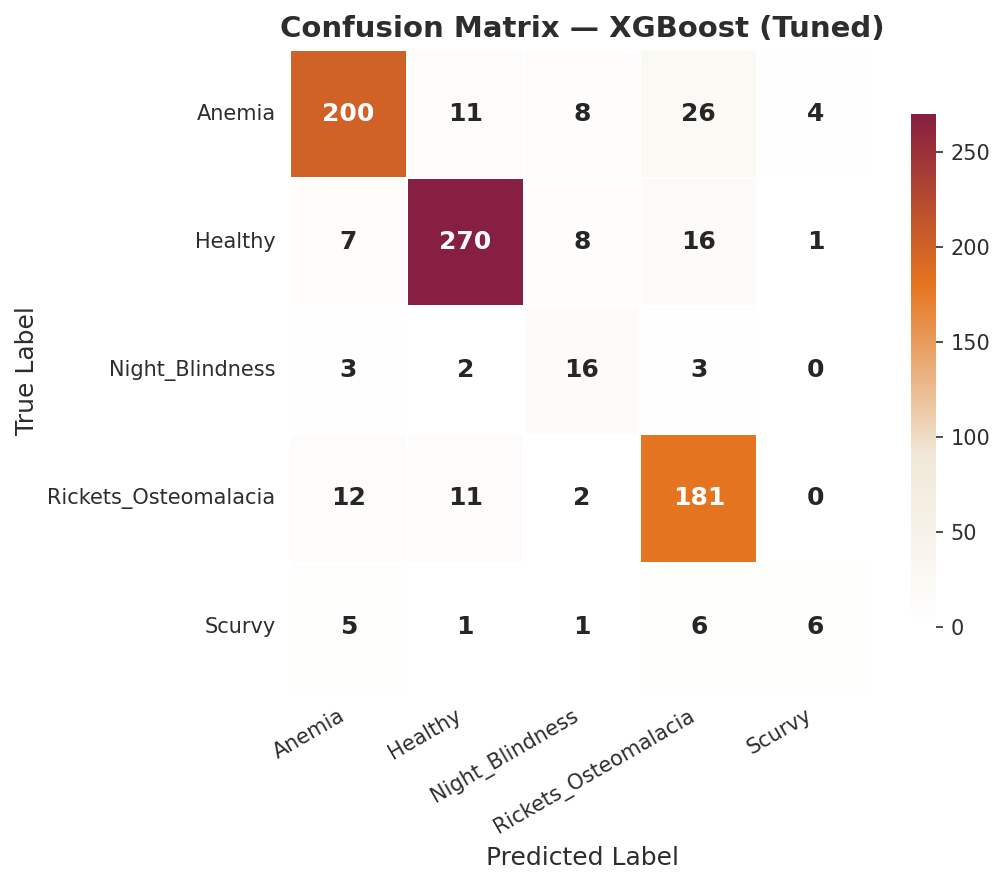


classification report — XGBoost (Tuned):
                      precision    recall  f1-score   support

              Anemia       0.88      0.80      0.84       249
             Healthy       0.92      0.89      0.90       302
     Night_Blindness       0.46      0.67      0.54        24
Rickets_Osteomalacia       0.78      0.88      0.83       206
              Scurvy       0.55      0.32      0.40        19

            accuracy                           0.84       800
           macro avg       0.72      0.71      0.70       800
        weighted avg       0.85      0.84      0.84       800



In [ ]:
# --- figure 4: confusion matrix for best model ---
fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap=vt_cmap,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.8, linecolor='white', ax=ax,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8})

ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(class_names, rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('/content/fig4_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nclassification report — {best_model_name}:')
print(classification_report(y_test, best_preds, target_names=class_names))

In [ ]:
# 5-fold cross validation on best model
print(f'5-fold cross validation — {best_model_name}\n')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train_resampled, y_train_resampled,
                            cv=cv, scoring='f1_macro')

for i, score in enumerate(cv_scores):
    print(f'  fold {i+1}: {score:.4f}')

print(f'\n  mean:  {cv_scores.mean():.4f}')
print(f'  std:   {cv_scores.std():.4f}')

5-fold cross validation — XGBoost (Tuned)

  fold 1: 0.9143
  fold 2: 0.9200
  fold 3: 0.9175
  fold 4: 0.9198
  fold 5: 0.9203

  mean:  0.9184
  std:   0.0023


computing shap values...



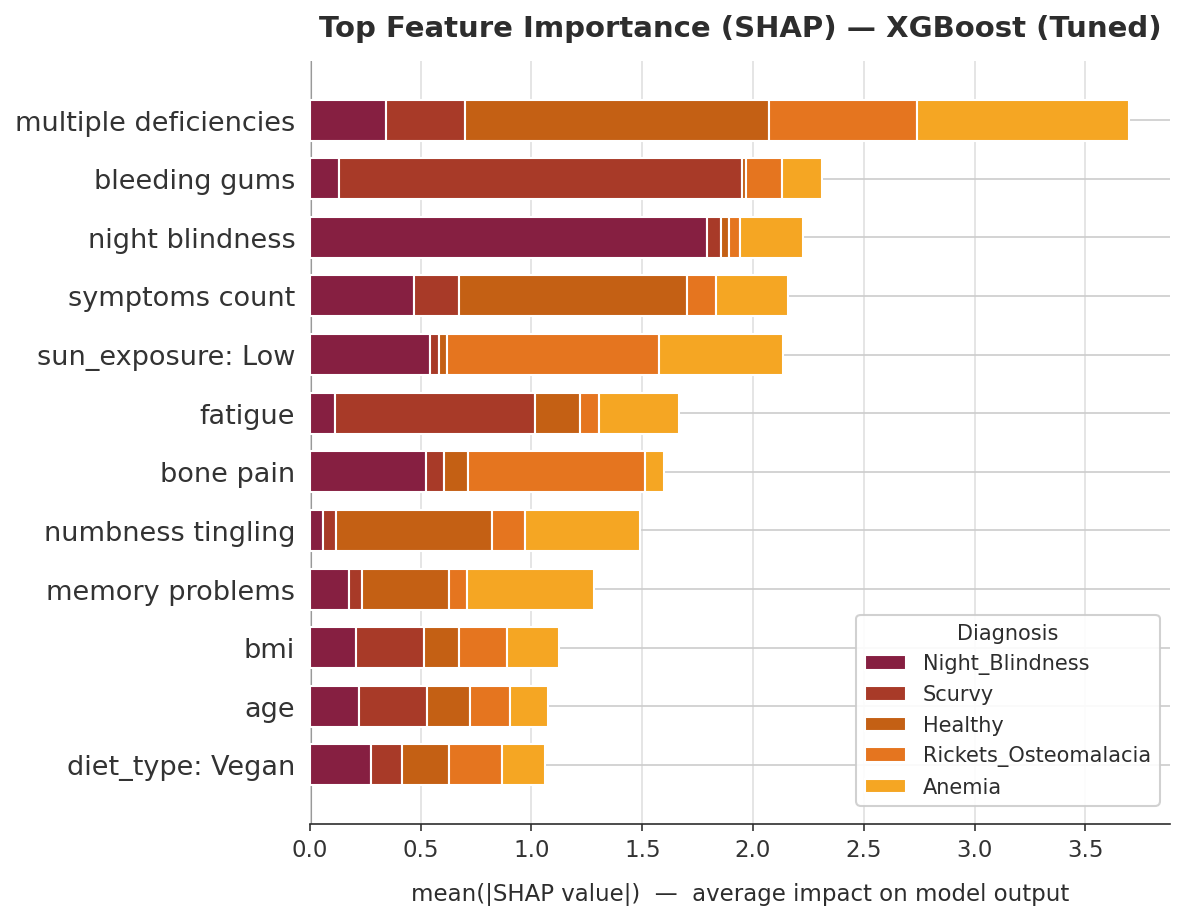

In [ ]:
# --- figure 5: shap feature importance ---
print('computing shap values...\n')

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

clean_names = []
for col in X_test_scaled.columns:
    name = col.replace('has_', '').replace('_', ' ')
    for cat in categorical_features:
        if col.startswith(f'{cat}_'):
            name = col.replace(f'{cat}_', f'{cat}: ')
    clean_names.append(name)

X_display = X_test_scaled.copy()
X_display.columns = clean_names

class_color_map = {
    'Anemia':               '#861F41',
    'Healthy':              '#A83A28',
    'Night_Blindness':      '#C46014',
    'Rickets_Osteomalacia': '#E5751F',
    'Scurvy':               '#F5A623',
}
bar_colors = [class_color_map[c] for c in class_names]
color_fn = lambda i: bar_colors[i % len(bar_colors)]

fig, ax = plt.subplots(figsize=(11, 8))

shap.summary_plot(shap_values, X_display, class_names=class_names,
                  plot_type='bar', show=False, max_display=12,
                  color=color_fn)

ax.set_title(f'Top Feature Importance (SHAP) — {best_model_name}',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('mean(|SHAP value|)  —  average impact on model output',
              fontsize=11, labelpad=10)

ax.legend(loc='lower right', bbox_to_anchor=(1.0, 0.01),
          frameon=True, framealpha=0.9, edgecolor='#CCCCCC',
          fontsize=10, title='Diagnosis', title_fontsize=10)

ax.xaxis.grid(True, color='#E0E0E0', linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.savefig('/content/fig5_shap_importance.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# save all artifacts for deployment
os.makedirs('/content/vitacheck_artifacts', exist_ok=True)

joblib.dump(best_model, '/content/vitacheck_artifacts/best_model.joblib')
joblib.dump(best_model, '/content/vitacheck_artifacts/xgb_tuned.joblib')
joblib.dump(scaler, '/content/vitacheck_artifacts/scaler.joblib')
joblib.dump(target_le, '/content/vitacheck_artifacts/target_label_encoder.joblib')

# feature_info already saved by the reload cell
# zip everything so you can download it
import shutil
shutil.make_archive('/content/vitacheck_artifacts', 'zip', '/content/vitacheck_artifacts')

print('saved artifacts:')
for f in os.listdir('/content/vitacheck_artifacts'):
    size = os.path.getsize(f'/content/vitacheck_artifacts/{f}')
    print(f'  {f} ({size/1024:.1f} KB)')

print('\n>>> DOWNLOAD /content/vitacheck_artifacts.zip <<<')

saved artifacts:
  best_model.joblib (3021.1 KB)
  feature_info.json (1.4 KB)
  target_label_encoder.joblib (0.5 KB)
  scaler.joblib (0.9 KB)
  xgb_tuned.joblib (3021.1 KB)

>>> DOWNLOAD /content/vitacheck_artifacts.zip <<<


In [ ]:
!zip -r /content/vitacheck_artifacts.zip /content/vitacheck_artifacts

  adding: content/vitacheck_artifacts/ (stored 0%)
  adding: content/vitacheck_artifacts/feature_info.json (deflated 70%)
  adding: content/vitacheck_artifacts/target_label_encoder.joblib (deflated 34%)
  adding: content/vitacheck_artifacts/scaler.joblib (deflated 38%)
  adding: content/vitacheck_artifacts/xgb_tuned.joblib (deflated 68%)


In [ ]:
!pip install -q gradio groq

In [25]:
# ============================================================================
# vitacheck — full gradio app with groq llm meal plan generation
# ============================================================================
import gradio as gr
import joblib
import pandas as pd
import numpy as np
import json
import os
from groq import Groq

# load artifacts
model = joblib.load('/content/vitacheck_artifacts/xgb_tuned.joblib')
scaler_obj = joblib.load('/content/vitacheck_artifacts/scaler.joblib')
target_le = joblib.load('/content/vitacheck_artifacts/target_label_encoder.joblib')

with open('/content/vitacheck_artifacts/feature_info.json', 'r') as f:
    info = json.load(f)

feature_columns = info['feature_columns']
class_names = info['class_names']
continuous_cols = info['continuous_cols']

# groq client — key will be set as huggingface space secret
GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "(place your api key here)")
groq_client = Groq(api_key=GROQ_API_KEY)


def generate_meal_plan(diagnosis, diet_type, allergies):
    """generate a personalized meal plan using groq llama 3.3"""
    prompt = f"""you are a clinical nutritionist. a patient has been screened and the result is: {diagnosis.replace('_', ' ')}.

patient details:
- diet type: {diet_type}
- allergies/restrictions: {allergies if allergies else 'none reported'}

create a personalized 3-day meal plan to address this condition. for each day provide breakfast, lunch, dinner, and one snack. after the meal plan, add a section called "key nutrients to focus on" explaining which vitamins/minerals to prioritize and why.

keep it practical with real recipes. use markdown formatting. do not use emojis."""

    try:
        response = groq_client.chat.completions.create(
            messages=[
                {"role": "system", "content": "you are a registered dietitian. give evidence-based, practical dietary advice. always remind patients this is not a substitute for professional medical care. do not use emojis."},
                {"role": "user", "content": prompt}
            ],
            model="llama-3.3-70b-versatile",
            temperature=0.7,
            max_tokens=2048
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"meal plan generation temporarily unavailable. try again in a moment.\n\nerror: {str(e)}"


# nutrient info per diagnosis
nutrient_info = {
    'Anemia': {'deficiency': 'iron, vitamin b12, folate',
               'foods': 'red meat, spinach, lentils, fortified cereals, eggs, dark leafy greens',
               'tip': 'pair iron-rich foods with vitamin c to boost absorption. avoid tea/coffee with meals.'},
    'Night_Blindness': {'deficiency': 'vitamin a',
                        'foods': 'carrots, sweet potatoes, spinach, kale, eggs, liver, mangoes',
                        'tip': 'vitamin a is fat-soluble — eat with healthy fats for better absorption.'},
    'Rickets_Osteomalacia': {'deficiency': 'vitamin d, calcium',
                             'foods': 'salmon, sardines, fortified milk, eggs, uv-exposed mushrooms',
                             'tip': 'aim for 15-20 min sunlight daily. consider a vitamin d supplement.'},
    'Scurvy': {'deficiency': 'vitamin c',
               'foods': 'oranges, strawberries, bell peppers, broccoli, kiwi, guava',
               'tip': 'vitamin c is heat-sensitive — eat fruits/vegetables raw or lightly cooked.'},
    'Healthy': {'deficiency': 'none detected',
                'foods': 'maintain a balanced diet with whole grains, lean proteins, fruits, vegetables',
                'tip': 'keep variety in your diet to cover all micronutrient needs.'}
}


def predict(age, gender, bmi, smoking, alcohol, exercise, diet, sun,
            income, latitude, night_blindness, fatigue, bleeding_gums,
            bone_pain, muscle_weakness, numbness_tingling, memory_problems,
            pale_skin, multiple_deficiencies, allergies):

    alcohol_map = {
        "none": "Unknown",
        "moderate": "Moderate",
        "heavy": "Heavy",
        "prefer not to say": "Unknown"
    }
    alcohol_mapped = alcohol_map.get(alcohol.lower(), "Unknown")

    symptoms = [night_blindness, fatigue, bleeding_gums, bone_pain,
                muscle_weakness, numbness_tingling, memory_problems,
                pale_skin, multiple_deficiencies]
    symptoms_count = sum(symptoms)

    row = {
        'age': age, 'bmi': bmi, 'symptoms_count': symptoms_count,
        'has_night_blindness': int(night_blindness),
        'has_fatigue': int(fatigue),
        'has_bleeding_gums': int(bleeding_gums),
        'has_bone_pain': int(bone_pain),
        'has_muscle_weakness': int(muscle_weakness),
        'has_numbness_tingling': int(numbness_tingling),
        'has_memory_problems': int(memory_problems),
        'has_pale_skin': int(pale_skin),
        'has_multiple_deficiencies': int(multiple_deficiencies),
    }

    categorical_values = {
        'gender': gender, 'smoking_status': smoking,
        'alcohol_consumption': alcohol_mapped, 'exercise_level': exercise,
        'diet_type': diet, 'sun_exposure': sun,
        'income_level': income, 'latitude_region': latitude,
    }

    # initialize all feature columns to 0
    for col in feature_columns:
        if col not in row:
            row[col] = 0

    # fixed: check against feature_columns, not row
    for cat_name, cat_value in categorical_values.items():
        col_name = f'{cat_name}_{cat_value}'
        if col_name in feature_columns:
            row[col_name] = 1

    df_input = pd.DataFrame([row])[feature_columns]
    df_input[continuous_cols] = scaler_obj.transform(df_input[continuous_cols])

    proba = model.predict_proba(df_input)[0]
    pred_idx = np.argmax(proba)
    pred_class = class_names[pred_idx]
    confidence = proba[pred_idx]

    conf_dict = {class_names[i]: float(proba[i]) for i in range(len(class_names))}
    rec = nutrient_info.get(pred_class, nutrient_info['Healthy'])

    diagnosis_md = f"""
## {pred_class.replace('_', ' ').lower()}

**confidence: {confidence*100:.1f}%**

---

**likely deficiency:** {rec['deficiency']}

**key foods:** {rec['foods']}

**quick tip:** {rec['tip']}
"""

    meal_plan = generate_meal_plan(pred_class, diet, allergies)

    return conf_dict, diagnosis_md, meal_plan


# custom css — dark green + black
css = """
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap');

* { box-sizing: border-box; }

.gradio-container {
    max-width: 1100px !important;
    margin: auto !important;
    background: #000000 !important;
    font-family: 'Inter', sans-serif !important;
    color: #d1d5db !important;
}

#header-row {
    background: #000000;
    border-radius: 16px;
    padding: 40px 36px 32px 36px;
    margin-bottom: 20px;
    border: 1px solid #1a2e1f;
    border-top: 3px solid #22c55e;
}
#header-row h1 {
    color: #4ade80 !important;
    font-size: 2.4em !important;
    margin-bottom: 4px !important;
    letter-spacing: -0.5px;
}
#header-row p {
    color: #9ca3af !important;
    font-size: 15px !important;
    margin: 0 !important;
    line-height: 1.6 !important;
}
#header-row em {
    color: #4b5563 !important;
    font-size: 13px !important;
}

/* all inputs */
input, textarea, select,
.gr-input, .gr-dropdown,
.gr-slider input,
input[type="text"],
input[type="number"],
input[type="range"] {
    background: #0a0a0a !important;
    border: 1px solid #1c1c1c !important;
    color: #d1d5db !important;
    border-radius: 8px !important;
}
input:focus, textarea:focus, select:focus {
    border-color: #22c55e !important;
    box-shadow: 0 0 0 2px rgba(34, 197, 94, 0.12) !important;
    outline: none !important;
}

/* primary button */
.gr-button-primary, button.primary {
    background: #16a34a !important;
    border: none !important;
    border-radius: 10px !important;
    padding: 14px 28px !important;
    font-size: 15px !important;
    font-weight: 600 !important;
    color: #fff !important;
    transition: all 0.2s ease !important;
}
.gr-button-primary:hover, button.primary:hover {
    background: #22c55e !important;
    box-shadow: 0 4px 16px rgba(34, 197, 94, 0.25) !important;
}

/* section titles */
.section-title {
    color: #4ade80 !important;
    font-size: 12px !important;
    font-weight: 700 !important;
    text-transform: uppercase;
    letter-spacing: 2px;
    margin-bottom: 10px !important;
    padding-bottom: 8px;
    border-bottom: 1px solid #1a2e1f;
}

/* labels and text */
label, .gr-checkbox label, .gr-radio label {
    color: #9ca3af !important;
    font-size: 13px !important;
}

/* checkboxes — fixed */
input[type="checkbox"] {
    accent-color: #22c55e !important;
    width: 16px !important;
    height: 16px !important;
}

input[type="checkbox"]:checked {
    background-color: #22c55e !important;
    border-color: #22c55e !important;
}

input[type="checkbox"]:checked + label,
input[type="checkbox"]:checked ~ label,
.gr-checkbox:has(input:checked) label,
label:has(input[type="checkbox"]:checked) {
    color: #4ade80 !important;
}

/* radio buttons — fixed */
input[type="radio"] {
    accent-color: #22c55e !important;
}

/* ADD THIS */
input[type="radio"]:checked {
    accent-color: #22c55e !important;
    background-color: #22c55e !important;
    border-color: #22c55e !important;
    box-shadow: inset 0 0 0 4px #000000, 0 0 0 2px #22c55e !important;
}

input[type="radio"]:checked + label,
input[type="radio"]:checked ~ label,
.gr-radio:has(input:checked) label,
label:has(input[type="radio"]:checked) {
    color: #4ade80 !important;
}


/* label output component */
.gr-label {
    background: #0a0a0a !important;
    border: 1px solid #1c1c1c !important;
    border-radius: 12px !important;
}

/* markdown output */
.prose { color: #d1d5db !important; }
.prose h2 { color: #4ade80 !important; border-bottom: 1px solid #1a2e1f; padding-bottom: 8px; }
.prose h3 { color: #86efac !important; }
.prose strong { color: #e5e7eb !important; }
.prose hr { border-color: #1a2e1f !important; }
.prose li { color: #d1d5db !important; }
.prose p { color: #d1d5db !important; }
.prose a { color: #4ade80 !important; }

/* tabs */
.tabs .tab-nav { border-bottom: 1px solid #1c1c1c !important; }
.tabs .tab-nav button {
    color: #6b7280 !important;
    font-weight: 600 !important;
    background: transparent !important;
    border: none !important;
    padding: 10px 20px !important;
    transition: color 0.2s !important;
}
.tabs .tab-nav button:hover { color: #9ca3af !important; }
.tabs .tab-nav button.selected {
    color: #4ade80 !important;
    border-bottom: 2px solid #4ade80 !important;
}

/* disclaimer */
.disclaimer {
    background: #0a0f0a !important;
    border: 1px solid #1a2e1f !important;
    border-left: 3px solid #ca8a04 !important;
    border-radius: 8px !important;
    padding: 14px 18px !important;
    margin-top: 16px;
    color: #6b7280 !important;
    font-size: 13px !important;
}
.disclaimer strong { color: #ca8a04 !important; }

/* panels and backgrounds */
.block, .gr-panel, .gr-form, .gr-box, .gr-padded,
.panel, .form, .wrap, .container {
    background: #000000 !important;
    border-color: #1c1c1c !important;
}
.gr-box { border-radius: 12px !important; }

/* slider track */
input[type="range"]::-webkit-slider-runnable-track {
    background: #1a2e1f !important;
}
input[type="range"]::-webkit-slider-thumb {
    background: #22c55e !important;
}

/* dividers */
hr { border-color: #1c1c1c !important; }

/* scrollbar */
::-webkit-scrollbar { width: 6px; }
::-webkit-scrollbar-track { background: #0a0a0a; }
::-webkit-scrollbar-thumb { background: #1a2e1f; border-radius: 3px; }
::-webkit-scrollbar-thumb:hover { background: #22c55e; }
"""

# build interface
with gr.Blocks(css=css, title="vitacheck", theme=gr.themes.Base()) as demo:

    with gr.Row(elem_id="header-row"):
        gr.Markdown("""
# vitacheck
**symptom-based vitamin deficiency detection & personalized meal planning**

virginia tech hci capstone — powered by xgboost + llama 3.3
        """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("<div class='section-title'>demographics</div>")
            age = gr.Slider(18, 84, value=30, step=1, label="age")
            gender = gr.Radio(["Male", "Female"], value="Male", label="gender")
            bmi = gr.Slider(15.0, 45.0, value=24.0, step=0.5, label="bmi")

            gr.Markdown("<div class='section-title'>lifestyle</div>")
            smoking = gr.Dropdown(["Never", "Former", "Current"], value="Never", label="smoking")
            alcohol = gr.Dropdown(["None", "Moderate", "Heavy", "Prefer not to say"],
                                  value="None", label="alcohol consumption")
            exercise = gr.Dropdown(["Sedentary", "Light", "Moderate", "Active"],
                                   value="Moderate", label="exercise")
            diet = gr.Dropdown(["Omnivore", "Vegetarian", "Vegan", "Pescatarian"],
                               value="Omnivore", label="diet type")

            gr.Markdown("<div class='section-title'>environment</div>")
            sun = gr.Dropdown(["Low", "Moderate", "High"], value="Moderate", label="sun exposure")
            income = gr.Dropdown(["Low", "Middle", "High"], value="Middle", label="income level")
            latitude = gr.Dropdown(["Low", "Mid", "High"], value="Mid", label="latitude region")

        with gr.Column(scale=1):
            gr.Markdown("<div class='section-title'>symptoms — check all that apply</div>")
            night_blindness = gr.Checkbox(label="night blindness / difficulty seeing in low light")
            fatigue = gr.Checkbox(label="fatigue / feeling unusually tired")
            bleeding_gums = gr.Checkbox(label="bleeding gums")
            bone_pain = gr.Checkbox(label="bone pain")
            muscle_weakness = gr.Checkbox(label="muscle weakness")
            numbness_tingling = gr.Checkbox(label="numbness or tingling")
            memory_problems = gr.Checkbox(label="memory problems / brain fog")
            pale_skin = gr.Checkbox(label="pale skin")
            multiple_deficiencies = gr.Checkbox(label="multiple symptoms / generally unwell")

            gr.Markdown("<div class='section-title'>dietary preferences</div>")
            allergies = gr.Textbox(
                label="allergies or restrictions",
                placeholder="e.g. lactose intolerant, nut allergy, gluten-free...",
                lines=2
            )

            submit_btn = gr.Button("analyze & generate meal plan", variant="primary", size="lg")

    gr.Markdown("---")

    with gr.Tabs():
        with gr.Tab("diagnosis"):
            with gr.Row():
                with gr.Column(scale=1):
                    confidence_output = gr.Label(label="confidence by class", num_top_classes=5)
                with gr.Column(scale=1):
                    diagnosis_output = gr.Markdown()

        with gr.Tab("personalized meal plan"):
            meal_plan_output = gr.Markdown()

    gr.Markdown("""
<div class='disclaimer'>
<strong>medical disclaimer:</strong> vitacheck is a screening tool for educational purposes only.
it is not a substitute for professional medical advice, diagnosis, or treatment.
always consult a qualified healthcare provider for proper evaluation.
</div>
    """)

    submit_btn.click(
        fn=predict,
        inputs=[age, gender, bmi, smoking, alcohol, exercise, diet, sun,
                income, latitude, night_blindness, fatigue, bleeding_gums,
                bone_pain, muscle_weakness, numbness_tingling, memory_problems,
                pale_skin, multiple_deficiencies, allergies],
        outputs=[confidence_output, diagnosis_output, meal_plan_output]
    )

demo.launch(share=True, debug=True)

/tmp/ipykernel_929/2007665704.py:359: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="vitacheck", theme=gr.themes.Base()) as demo:
/tmp/ipykernel_929/2007665704.py:359: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="vitacheck", theme=gr.themes.Base()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f5f82b5a37f9d9e32a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://f5f82b5a37f9d9e32a.gradio.live
